# (IIP314W-2) [2026-T2] OPTIMIZACIÓN APLICADA A NEGOCIOS
## Ayudantía 4: Modelamiento matemático de programación lineal — Pauta (Solución)

---

**Profesor:** Rodrigo Trigo Vilches

**Ayudante:** Vicente Ramírez

**Fecha:** 24 de junio de 2026

**Universidad del Desarrollo**

---

## Objetivos de la ayudantía

- Traducir un problema de negocios a un modelo de **programación lineal**: conjuntos, parámetros, variables de decisión, función objetivo y restricciones.
- Escribir el modelo de forma **algebraica** (paramétrica, en notación de sumatorias), **sin valores numéricos**: separar la *estructura* del modelo de los *datos*.
- Distinguir los tipos de restricciones típicas: **capacidad** ($\le$), **requerimiento/cobertura** ($\ge$) y **logística**.
- Implementar el modelo **genéricamente** en `gurobipy`, leyendo los datos desde archivos **CSV**.
- Interpretar la solución y los **precios sombra** (`.Pi`) de los recursos, conectando con la Ayudantía 3 (KKT).

## Repaso: elementos de un modelo (Clase 9)

| Elemento | Qué es |
|:--|:--|
| **Conjuntos / índices** | sobre qué corren las variables y restricciones (productos, plantas, misiones, …) |
| **Parámetros** | datos conocidos: costos, capacidades, demandas, precios (los escribimos con **letras**, no números) |
| **Variables de decisión** | lo que se busca |
| **Función objetivo** | qué se minimiza o maximiza |
| **Restricciones** | lo que debe cumplirse |

**Sobre los tipos de variable (importante).** En las Clases 9–10, **todas** las variables de decisión son **continuas** ($x \ge 0$). Las variables **enteras** solo se mencionaron al pasar (los manteles, Clase 10) sin desarrollar un método; y las variables **binarias**, las **restricciones de activación** (relación binaria–continua) y la técnica **"big-M"** **no se han visto en clase**. Por lo tanto, en esta ayudantía usamos **únicamente variables continuas no negativas**.

**Tipos de restricción que usaremos:**
- **Capacidad / disponibilidad** ($\sum \le b$): un recurso que no se puede sobrepasar.
- **Requerimiento / cobertura** ($\sum \ge d$): una exigencia mínima que cumplir.
- **Logística** ($\sum \le$ capacidad): transporte o almacenamiento que limita el flujo.

## Metodología: modelo algebraico + datos en CSV

Para que el modelo sea **100% algebraico**, los números **no** se escriben en el notebook. Se generan con el script **`generar_datos_ayudantia4.py`** (semilla fija, con **factibilidad garantizada**) y se guardan como **CSV** en la carpeta `datos_ayudantia4/`. El modelo en `gurobipy` **lee** esos CSV y se arma con `addVars` y `quicksum` sobre los conjuntos — sin números "a mano".

> Para (re)generar los datos, ejecutar en la terminal:
> ```
> py -3.13 generar_datos_ayudantia4.py
> ```
> Cambiar la semilla `SEED` dentro del script produce otra instancia (también factible) sin tocar el modelo.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB

DATA = "datos_ayudantia4"   # carpeta con los CSV generados por el script

## Ejercicio 1 — Planificación de entrenamiento militar (minimizar costos)

Una base de la **Fuerza Aérea** debe planificar, al **mínimo costo**, las **horas de vuelo de entrenamiento** del próximo trimestre para mantener certificadas a sus tripulaciones. La base opera un conjunto de aeronaves $\mathcal{A}$ —un caza, un helicóptero y un avión de transporte— y debe acumular horas en un conjunto de misiones $\mathcal{M}$: navegación, tiro real y asalto. No toda aeronave puede ejecutar toda misión (el transporte, por ejemplo, no realiza tiro), de modo que solo se consideran los pares **compatibles** $(i,j)\in\mathcal{C}$.

Volar una hora la aeronave $i$ tiene tres componentes de costo. Primero, el **combustible**: cada aeronave consume $f_i$ litros por hora de vuelo, y el litro cuesta $p$ (el mismo precio para todas). Segundo, la **operación y mantención**, $o_i$ por hora de la aeronave $i$. Tercero, en las misiones de tiro se gastan **municiones**, con un costo de $a_{ij}$ por hora (cero en las misiones que no disparan). Así, el costo por hora de cada par compatible resulta $\;c_{ij} = f_i\,p + o_i + a_{ij}$.

Las exigencias del plan son las siguientes. Cada misión $j$ requiere acumular al menos $r_j$ horas para certificar a las tripulaciones. Cada aeronave $i$ tiene, por mantenimiento y vida útil, un tope de $H_i$ horas de vuelo en el trimestre; y, para no perder la habilitación de sus pilotos, debe volar **al menos** $\underline{H}_i$ horas (este piso es relevante para el caza; para las demás aeronaves es 0). La logística de **combustible** también limita: el trimestre dispone de $Q$ litros en total. Por último, las **municiones** son finitas: cada hora de tiro de la aeronave $i$ consume $m_i$ proyectiles, y el stock disponible es de $S$ unidades.

**Tareas:** (1) definir las variables; (2) plantear FO y restricciones **algebraicamente**; (3) implementar en `gurobipy` leyendo los CSV y resolver; (4) identificar qué recursos son el **cuello de botella**.

### Formulación

**Variables de decisión** (continuas, no negativas):
$$x_{ij} \ge 0:\quad \text{horas de vuelo de la misión } j \text{ realizadas con la aeronave } i,\qquad (i,j)\in\mathcal{C}.$$

**Función objetivo** — minimizar el costo total:
$$\min\; \sum_{(i,j)\in\mathcal{C}} c_{ij}\,x_{ij} \;=\; \sum_{(i,j)\in\mathcal{C}} \big(f_i\,p + o_i + a_{ij}\big)\,x_{ij}.$$

**Restricciones:**

- **Requerimiento de certificación** por misión (cobertura, $\ge$):
$$\sum_{i:\,(i,j)\in\mathcal{C}} x_{ij} \;\ge\; r_j \qquad \forall j\in\mathcal{M}.$$

- **Disponibilidad de horas** por aeronave (capacidad, $\le$):
$$\sum_{j:\,(i,j)\in\mathcal{C}} x_{ij} \;\le\; H_i \qquad \forall i\in\mathcal{A}.$$

- **Combustible** total disponible (logística, $\le$):
$$\sum_{(i,j)\in\mathcal{C}} f_i\,x_{ij} \;\le\; Q.$$

- **Stock de municiones** (sobre las misiones de tiro, $\le$):
$$\sum_{i:\,(i,\,\text{Tiro})\in\mathcal{C}} m_i\,x_{i,\text{Tiro}} \;\le\; S.$$

- **Horas mínimas de certificación** por aeronave ($\ge$):
$$\sum_{j:\,(i,j)\in\mathcal{C}} x_{ij} \;\ge\; \underline{H}_i \qquad \forall i:\ \underline{H}_i>0.$$

- **No negatividad:** $x_{ij}\ge 0$.

In [2]:
# Cargar los datos del Ejercicio 1 desde los CSV
aero = pd.read_csv(f"{DATA}/mil_aeronaves.csv")   # aeronave, f, o, H, m, Hmin
mis  = pd.read_csv(f"{DATA}/mil_misiones.csv")     # mision, r
comp = pd.read_csv(f"{DATA}/mil_compat.csv")       # aeronave, mision, a  (pares compatibles)
esc  = pd.read_csv(f"{DATA}/mil_escalares.csv").set_index("parametro")["valor"]

display(aero); display(mis); display(comp); print(esc)

,aeronave,f,o,H,m,Hmin
0,Caza,3170,4239,131,538,60
1,Helicoptero,853,1412,117,276,0
2,Transporte,1563,1908,66,0,0


,mision,r
0,Navegacion,113
1,Tiro,72
2,Asalto,51


,aeronave,mision,a
0,Caza,Navegacion,0
1,Caza,Tiro,8485
2,Helicoptero,Navegacion,0
3,Helicoptero,Tiro,3327
4,Helicoptero,Asalto,0
5,Transporte,Navegacion,0
6,Transporte,Asalto,0


parametro
precio_combustible         1.56
combustible_total     547981.00
stock_municiones       34037.00
Name: valor, dtype: float64


In [3]:
# --- Conjuntos y parametros desde los CSV ---
A = list(aero["aeronave"]); M = list(mis["mision"])
f    = dict(zip(aero.aeronave, aero.f));    o    = dict(zip(aero.aeronave, aero.o))
H    = dict(zip(aero.aeronave, aero.H));    mpro = dict(zip(aero.aeronave, aero.m))
Hmin = dict(zip(aero.aeronave, aero.Hmin)); r    = dict(zip(mis.mision, mis.r))
pares = list(zip(comp.aeronave, comp.mision))
a = {(t.aeronave, t.mision): t.a for t in comp.itertuples()}
p = esc["precio_combustible"]; Q = esc["combustible_total"]; S = esc["stock_municiones"]

# --- Modelo ---
mdl = gp.Model("entrenamiento_militar")
mdl.setParam("OutputFlag", 0)
x = mdl.addVars(pares, lb=0, name="x")                       # horas (continuas, >= 0)

# costo por hora:  c_ij = f_i * p + o_i + a_ij
c = {(i, j): f[i]*p + o[i] + a[(i, j)] for (i, j) in pares}
mdl.setObjective(gp.quicksum(c[i, j]*x[i, j] for (i, j) in pares), GRB.MINIMIZE)

# (1) requerimiento de horas por mision  (>=)
req = {j: mdl.addConstr(gp.quicksum(x[i, jj] for (i, jj) in pares if jj == j) >= r[j],
                        name=f"req_{j}") for j in M}
# (2) disponibilidad de horas por aeronave  (<=)
disp = {i: mdl.addConstr(gp.quicksum(x[ii, jj] for (ii, jj) in pares if ii == i) <= H[i],
                         name=f"disp_{i}") for i in A}
# (3) combustible total disponible  (logistica, <=)
comb = mdl.addConstr(gp.quicksum(f[i]*x[i, j] for (i, j) in pares) <= Q, name="combustible")
# (4) stock de municiones, sobre misiones de tiro  (<=)
muni = mdl.addConstr(gp.quicksum(mpro[i]*x[i, j] for (i, j) in pares if j == "Tiro") <= S,
                     name="municiones")
# (5) horas minimas de certificacion por aeronave  (>=)
cmin = {i: mdl.addConstr(gp.quicksum(x[ii, jj] for (ii, jj) in pares if ii == i) >= Hmin[i],
                         name=f"min_{i}") for i in A if Hmin[i] > 0}

mdl.optimize()
print("Estado:", mdl.Status, "(2 = optimo)")
print("Costo minimo total = $", round(mdl.ObjVal, 1))

Set parameter Username


Academic license - for non-commercial use only - expires 2027-06-10


Estado: 2 (2 = optimo)
Costo minimo total = $ 1367920.1


In [4]:
# Plan de horas por (aeronave, mision)
filas = [(i, j, round(x[i, j].X, 2), round(c[i, j], 1)) for (i, j) in pares]
plan = pd.DataFrame(filas, columns=["aeronave", "mision", "horas", "costo_$/h"])
plan = plan[plan.horas > 1e-6].sort_values(["aeronave", "mision"]).reset_index(drop=True)
display(plan)

# Que restricciones quedan ACTIVAS (cuello de botella)
print("Requerimientos de mision (usado >= r):")
for j in M:
    print(f"  {j:11s}: usado {sum(x[i,jj].X for (i,jj) in pares if jj==j):6.1f}  >= {r[j]}")
print("\nDisponibilidad de aeronaves (usado <= H):")
for i in A:
    usado = sum(x[ii,jj].X for (ii,jj) in pares if ii==i)
    estado = "<-- ACTIVA (tope)" if abs(usado - H[i]) < 1e-6 else ""
    print(f"  {i:11s}: usado {usado:6.1f}  <= {H[i]:4.0f}   {estado}")
print(f"\nCombustible: usado {sum(f[i]*x[i,j].X for (i,j) in pares):.0f}  <= {Q:.0f}")
print(f"Municiones : usado {sum(mpro[i]*x[i,j].X for (i,j) in pares if j=='Tiro'):.0f}  <= {S:.0f}")
print(f"Caza (horas minimas de certificacion): {sum(x[i,j].X for (i,j) in pares if i=='Caza'):.1f}  >= {Hmin['Caza']:.0f}")

,aeronave,mision,horas,costo_$/h
0,Caza,Navegacion,60.0,9184.2
1,Helicoptero,Asalto,45.0,2742.7
2,Helicoptero,Tiro,72.0,6069.7
3,Transporte,Asalto,6.0,4346.3
4,Transporte,Navegacion,53.0,4346.3


Requerimientos de mision (usado >= r):
  Navegacion : usado  113.0  >= 113
  Tiro       : usado   72.0  >= 72
  Asalto     : usado   51.0  >= 51

Disponibilidad de aeronaves (usado <= H):
  Caza       : usado   60.0  <=  131   
  Helicoptero: usado  117.0  <=  117   <-- ACTIVA (tope)
  Transporte : usado   59.0  <=   66   

Combustible: usado 382218  <= 547981
Municiones : usado 19872  <= 34037
Caza (horas minimas de certificacion): 60.0  >= 60


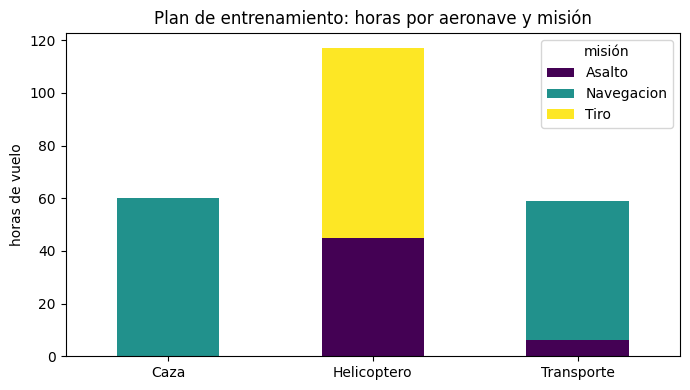

In [5]:
# Horas por aeronave, desglosadas por mision
piv = plan.pivot_table(index="aeronave", columns="mision", values="horas", aggfunc="sum").fillna(0)
piv.plot(kind="bar", stacked=True, figsize=(7, 4), colormap="viridis")
plt.ylabel("horas de vuelo"); plt.xlabel("")
plt.title("Plan de entrenamiento: horas por aeronave y misión")
plt.xticks(rotation=0); plt.legend(title="misión"); plt.tight_layout(); plt.show()

### Discusión

La estructura del óptimo revela los **cuellos de botella**. El **helicóptero** es la aeronave más barata por hora en casi toda misión (poco combustible y baja operación), así que el modelo lo usa **al máximo de su disponibilidad** ($\sum_j x_{\text{Heli},j} = H_{\text{Heli}}$, restricción **activa**), concentrando en él el tiro y el asalto. El **caza**, mucho más caro (alto consumo + municiones), solo vuela porque la restricción de **horas mínimas de certificación** $\underline{H}_{\text{Caza}}$ lo obliga, y lo hace en su misión más barata (**navegación**), no en tiro. El **transporte** cubre la navegación restante que el helicóptero, ya saturado, no alcanza. El **combustible** $Q$ y el **stock de municiones** $S$ quedan con **holgura**: no limitan en esta instancia.

**Lecciones de modelamiento:** (i) separar la *estructura algebraica* de los *datos* (CSV) permite re-resolver otra instancia sin tocar el modelo; (ii) leer qué restricciones quedan **activas** dice dónde conviene invertir — aquí, más horas de helicóptero rendirían más que más combustible.

## Ejercicio 2 — Distribución de una empresa de helados (maximizar ingresos)

Una **empresa de helados** quiere planificar su distribución para **maximizar los ingresos** de la temporada. Elabora un conjunto de productos $\mathcal{P}$ —una línea premium y una clásica— en un conjunto de plantas $\mathcal{K}$, y los vende en un conjunto de mercados $\mathcal{I}$. La decisión es cuántas **cajas** de cada producto despachar desde cada planta hacia cada mercado.

El precio de venta depende del producto y del mercado: una caja del producto $p$ se vende a $\pi_{pi}$ en el mercado $i$ (la línea premium se paga más, y algunos mercados pagan mejor que otros). Como interesa la **facturación** y no la utilidad, **no se descuentan costos** en la función objetivo; el costo logístico aparece, en cambio, como una **restricción de capacidad**.

Del lado de la **oferta**, cada planta $k$ puede producir a lo más $C_{pk}$ cajas del producto $p$. Del lado de la **demanda**, el mercado $i$ no absorbe más de $D_{pi}$ cajas del producto $p$ (despachar por sobre ese tope no genera ingreso). Y en el medio está la **cadena de frío**: todo viaja en camiones refrigerados, cada caja del producto $p$ ocupa $v_p$ metros cúbicos, y la flota refrigerada asignada a la planta $k$ tiene una capacidad total de $L_k$ m³ por temporada.

**Tareas:** (1) definir variables; (2) formular FO y restricciones **algebraicamente**; (3) implementar leyendo los CSV y resolver; (4) interpretar los **precios sombra** (`.Pi`) de la flota y de la demanda (conexión con la Ayudantía 3).

### Formulación

**Variables de decisión** (continuas, no negativas):
$$x_{pki} \ge 0:\quad \text{cajas del producto } p \text{ enviadas desde la planta } k \text{ al mercado } i.$$

**Función objetivo** — maximizar los **ingresos**:
$$\max\; \sum_{p\in\mathcal{P}}\sum_{k\in\mathcal{K}}\sum_{i\in\mathcal{I}} \pi_{pi}\,x_{pki}.$$

**Restricciones:**

- **Capacidad de producción** por planta y producto (capacidad, $\le$):
$$\sum_{i\in\mathcal{I}} x_{pki} \;\le\; C_{pk} \qquad \forall p\in\mathcal{P},\ k\in\mathcal{K}.$$

- **Tope de demanda** por mercado y producto (no se vende más de lo que el mercado absorbe, $\le$):
$$\sum_{k\in\mathcal{K}} x_{pki} \;\le\; D_{pi} \qquad \forall p\in\mathcal{P},\ i\in\mathcal{I}.$$

- **Capacidad de la flota refrigerada** por planta (logística, $\le$):
$$\sum_{p\in\mathcal{P}}\sum_{i\in\mathcal{I}} v_p\,x_{pki} \;\le\; L_k \qquad \forall k\in\mathcal{K}.$$

- **No negatividad:** $x_{pki}\ge 0$.

In [6]:
# Cargar los datos del Ejercicio 2 desde los CSV
prec = pd.read_csv(f"{DATA}/helados_precios.csv")     # producto, mercado, precio
prod = pd.read_csv(f"{DATA}/helados_produccion.csv")  # producto, planta, capacidad
dem  = pd.read_csv(f"{DATA}/helados_demanda.csv")      # producto, mercado, demanda
vol  = pd.read_csv(f"{DATA}/helados_volumen.csv")      # producto, volumen
flo  = pd.read_csv(f"{DATA}/helados_flota.csv")        # planta, capacidad_m3

display(prec); display(prod); display(dem); display(vol); display(flo)

,producto,mercado,precio
0,Premium,Norte,31
1,Premium,Centro,29
2,Premium,Sur,31
3,Clasico,Norte,17
4,Clasico,Centro,14
5,Clasico,Sur,15


,producto,planta,capacidad
0,Premium,Santiago,3618
1,Premium,Concepcion,3635
2,Clasico,Santiago,4332
3,Clasico,Concepcion,6078


,producto,mercado,demanda
0,Premium,Norte,1947
1,Premium,Centro,2799
2,Premium,Sur,2339
3,Clasico,Norte,3480
4,Clasico,Centro,3318
5,Clasico,Sur,3392


,producto,volumen
0,Premium,0.050
1,Clasico,0.042


,planta,capacidad_m3
0,Santiago,228
1,Concepcion,205


In [7]:
# --- Conjuntos y parametros desde los CSV ---
P = list(vol["producto"]); K = list(flo["planta"]); I = list(dict.fromkeys(prec["mercado"]))
pi = {(t.producto, t.mercado): t.precio for t in prec.itertuples()}
C  = {(t.producto, t.planta):  t.capacidad for t in prod.itertuples()}
D  = {(t.producto, t.mercado): t.demanda for t in dem.itertuples()}
v  = dict(zip(vol.producto, vol.volumen))
L  = dict(zip(flo.planta, flo.capacidad_m3))

# --- Modelo ---
mdl = gp.Model("helados_ingresos")
mdl.setParam("OutputFlag", 0)
x = mdl.addVars(P, K, I, lb=0, name="x")                     # cajas (continuas, >= 0)

# maximizar ingresos
mdl.setObjective(gp.quicksum(pi[p, i]*x[p, k, i] for p in P for k in K for i in I),
                 GRB.MAXIMIZE)

# (1) capacidad de produccion por (producto, planta)  (<=)
prodC = {(p, k): mdl.addConstr(gp.quicksum(x[p, k, i] for i in I) <= C[p, k], name=f"prod_{p}_{k}")
         for p in P for k in K}
# (2) tope de demanda por (producto, mercado)  (<=)
demC = {(p, i): mdl.addConstr(gp.quicksum(x[p, k, i] for k in K) <= D[p, i], name=f"dem_{p}_{i}")
        for p in P for i in I}
# (3) capacidad de la flota refrigerada por planta  (logistica, <=)
floC = {k: mdl.addConstr(gp.quicksum(v[p]*x[p, k, i] for p in P for i in I) <= L[k], name=f"flota_{k}")
        for k in K}

mdl.optimize()
print("Estado:", mdl.Status, "(2 = optimo)")
print("Ingreso maximo total = $", round(mdl.ObjVal, 1), "(miles)")

Estado: 2 (2 = optimo)
Ingreso maximo total = $ 245912.0 (miles)


In [8]:
# Plan de despacho (cajas) por (producto, planta, mercado)
filas = [(p, k, i, round(x[p, k, i].X, 1))
         for p in P for k in K for i in I if x[p, k, i].X > 1e-6]
envios = pd.DataFrame(filas, columns=["producto", "planta", "mercado", "cajas"])
display(envios)

# Precios sombra (.Pi) -> mismo concepto que los multiplicadores KKT de la Ayudantia 3
print("Flota refrigerada (.Pi = ingreso extra por 1 m3 adicional de transporte):")
for k in K:
    usado = sum(v[p]*x[p, k, i].X for p in P for i in I)
    print(f"  Planta {k:11s}: usado {usado:6.1f} / {L[k]:.0f} m3   ->  Pi = {floC[k].Pi:.2f}")

print("\nDemanda saturada (.Pi > 0  =>  mercado tope para ese producto):")
for (p, i) in demC:
    if demC[(p, i)].Pi > 1e-6:
        print(f"  {p:8s} en {i:7s}: Pi = {demC[(p, i)].Pi:.2f}")

,producto,planta,mercado,cajas
0,Premium,Santiago,Centro,1111.0
1,Premium,Santiago,Sur,2339.0
2,Premium,Concepcion,Norte,1947.0
3,Premium,Concepcion,Centro,1688.0
4,Clasico,Santiago,Norte,1321.4
5,Clasico,Concepcion,Norte,553.6


Flota refrigerada (.Pi = ingreso extra por 1 m3 adicional de transporte):
  Planta Santiago   : usado  228.0 / 228 m3   ->  Pi = 404.76
  Planta Concepcion : usado  205.0 / 205 m3   ->  Pi = 404.76

Demanda saturada (.Pi > 0  =>  mercado tope para ese producto):
  Premium  en Norte  : Pi = 10.76
  Premium  en Centro : Pi = 8.76
  Premium  en Sur    : Pi = 10.76


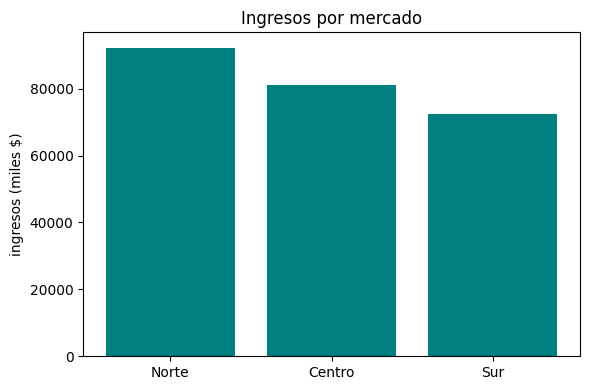

In [9]:
# Ingresos por mercado
ing = {i: 0.0 for i in I}
for p in P:
    for k in K:
        for i in I:
            ing[i] += pi[p, i]*x[p, k, i].X
plt.figure(figsize=(6, 4))
plt.bar(list(ing.keys()), list(ing.values()), color="teal")
plt.ylabel("ingresos (miles $)"); plt.title("Ingresos por mercado")
plt.tight_layout(); plt.show()

### Discusión

Maximizamos **ingresos** (no ganancias): por eso el costo logístico no aparece en la función objetivo, sino como la **capacidad de la flota refrigerada** $L_k$ (una restricción). El óptimo despacha **todo el producto premium posible** —tiene mayor precio y, sobre todo, mayor ingreso por m³ de transporte— hasta saturar la **demanda premium**, y recién con la capacidad de flota sobrante mueve el **clásico**, priorizando el mercado donde se paga más.

Las restricciones **activas** son la **flota** de las plantas y la **demanda premium**. Su **precio sombra** `.Pi` —el mismo concepto que el multiplicador KKT de la Ayudantía 3— cuantifica el negocio:
- el `.Pi` de la **flota** dice cuántos miles de \$ extra de ingreso daría **1 m³ adicional** de transporte refrigerado (la inversión logística más rentable);
- el `.Pi` de la **demanda premium** dice cuánto valdría **ampliar en 1 caja** ese mercado.

Y, tal como en KKT: las restricciones con **holgura** tienen `.Pi = 0` (ampliarlas no aporta nada), y las **activas** tienen `.Pi > 0`.